In [19]:
import pandas as pd

telco_df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Dataset loaded successfully!")
print("Rows and columns:", telco_df.shape)

telco_df.head()

Dataset loaded successfully!
Rows and columns: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [20]:
telco_df.info()

print("\nMissing values:")
print(telco_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [21]:
telco_df['TotalCharges'] = pd.to_numeric(
    telco_df['TotalCharges'],
    errors='coerce'
)

print("Missing TotalCharges values:",
      telco_df['TotalCharges'].isnull().sum())

Missing TotalCharges values: 11


In [22]:
telco_df = telco_df.dropna()

print("New dataset shape:", telco_df.shape)

New dataset shape: (7032, 21)


In [23]:
telco_df = telco_df.drop('customerID', axis=1)

telco_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [24]:
telco_df['Churn'] = telco_df['Churn'].map({
    'Yes': 1,
    'No': 0
})

print(telco_df['Churn'].value_counts())

Churn
0    5163
1    1869
Name: count, dtype: int64


In [25]:
X = telco_df.drop('Churn', axis=1)
y = telco_df['Churn']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7032, 19)
Target shape: (7032,)


In [26]:
X = pd.get_dummies(X, drop_first=True)

print("Encoded features:", X.shape)

X.head()

Encoded features: (7032, 30)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 5625
Testing samples: 1407


In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")

Scaling completed.


In [29]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

logistic_predictions = logistic_model.predict(X_test_scaled)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [30]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_test)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [31]:
from sklearn.ensemble import RandomForestClassifier

forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

forest_model.fit(X_train, y_train)

forest_predictions = forest_model.predict(X_test)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [34]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def evaluate_model(y_true, predictions):

    accuracy = accuracy_score(y_true, predictions)
    precision = precision_score(y_true, predictions)
    recall = recall_score(y_true, predictions)
    f1 = f1_score(y_true, predictions)

    return accuracy, precision, recall, f1

In [33]:
logistic_results = evaluate_model(
    y_test,
    logistic_predictions
)

tree_results = evaluate_model(
    y_test,
    tree_predictions
)

forest_results = evaluate_model(
    y_test,
    forest_predictions
)

print("Evaluation completed.")

Evaluation completed.


In [35]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],

    'Accuracy': [
        logistic_results[0],
        tree_results[0],
        forest_results[0]
    ],

    'Precision': [
        logistic_results[1],
        tree_results[1],
        forest_results[1]
    ],

    'Recall': [
        logistic_results[2],
        tree_results[2],
        forest_results[2]
    ],

    'F1-score': [
        logistic_results[3],
        tree_results[3],
        forest_results[3]
    ]
})

results.round(4)

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.8038,0.6476,0.5749,0.6091
1,Decision Tree,0.7186,0.4701,0.4626,0.4663
2,Random Forest,0.7868,0.6209,0.5080,0.5588


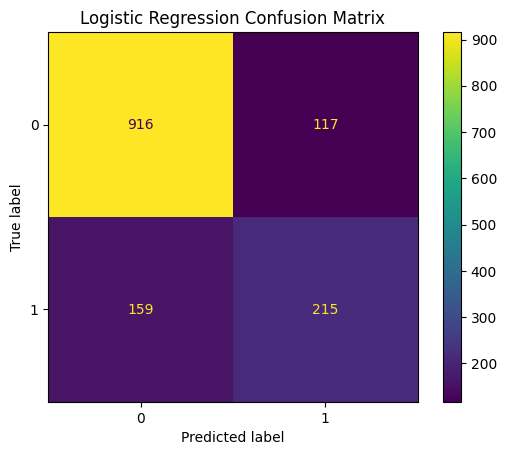

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_predictions
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

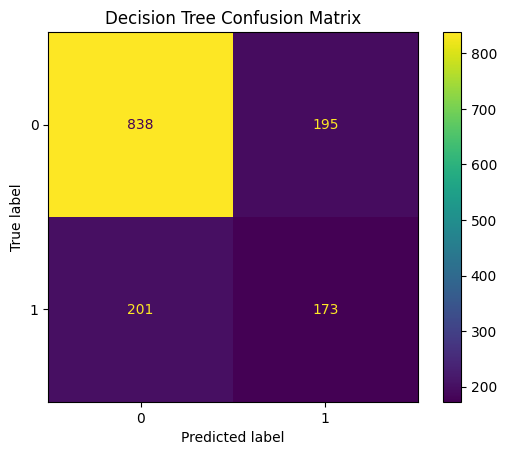

In [37]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    tree_predictions
)

plt.title("Decision Tree Confusion Matrix")
plt.show()

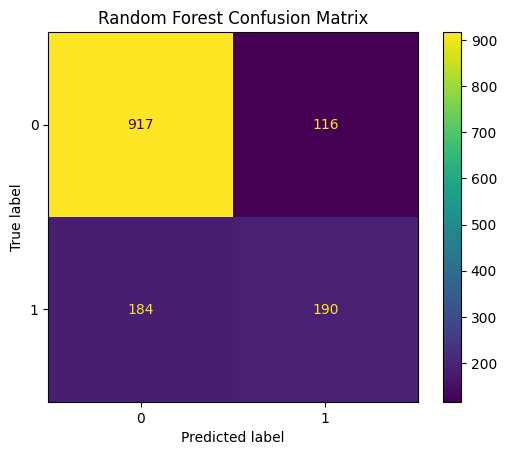

In [38]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    forest_predictions
)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [40]:
logistic_probabilities = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

tree_probabilities = tree_model.predict_proba(
    X_test
)[:, 1]

forest_probabilities = forest_model.predict_proba(
    X_test
)[:, 1]

In [41]:
from sklearn.metrics import roc_auc_score

logistic_auc = roc_auc_score(
    y_test,
    logistic_probabilities
)

tree_auc = roc_auc_score(
    y_test,
    tree_probabilities
)

forest_auc = roc_auc_score(
    y_test,
    forest_probabilities
)

print("Logistic Regression ROC-AUC:",
      round(logistic_auc, 4))

print("Decision Tree ROC-AUC:",
      round(tree_auc, 4))

print("Random Forest ROC-AUC:",
      round(forest_auc, 4))

Logistic Regression ROC-AUC: 0.8357
Decision Tree ROC-AUC: 0.6366
Random Forest ROC-AUC: 0.8181


In [42]:
results['ROC-AUC'] = [
    logistic_auc,
    tree_auc,
    forest_auc
]

results.round(4)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.8038,0.6476,0.5749,0.6091,0.8357
1,Decision Tree,0.7186,0.4701,0.4626,0.4663,0.6366
2,Random Forest,0.7868,0.6209,0.5080,0.5588,0.8181


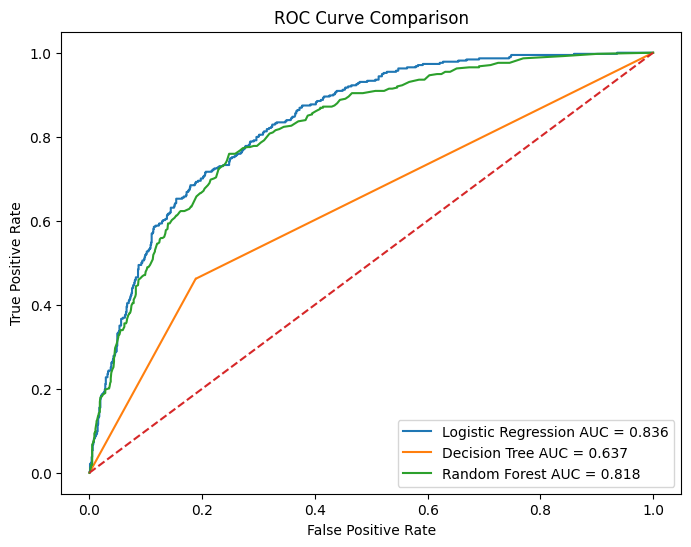

In [43]:
from sklearn.metrics import roc_curve

log_fpr, log_tpr, _ = roc_curve(
    y_test,
    logistic_probabilities
)

tree_fpr, tree_tpr, _ = roc_curve(
    y_test,
    tree_probabilities
)

forest_fpr, forest_tpr, _ = roc_curve(
    y_test,
    forest_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    log_fpr,
    log_tpr,
    label=f'Logistic Regression AUC = {logistic_auc:.3f}'
)

plt.plot(
    tree_fpr,
    tree_tpr,
    label=f'Decision Tree AUC = {tree_auc:.3f}'
)

plt.plot(
    forest_fpr,
    forest_tpr,
    label=f'Random Forest AUC = {forest_auc:.3f}'
)

plt.plot([0, 1], [0, 1], '--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()

plt.show()